In [3]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
df = df[df['job_title_short']=='Data Analyst']

In [5]:
df_exploded= df.explode('job_skills')

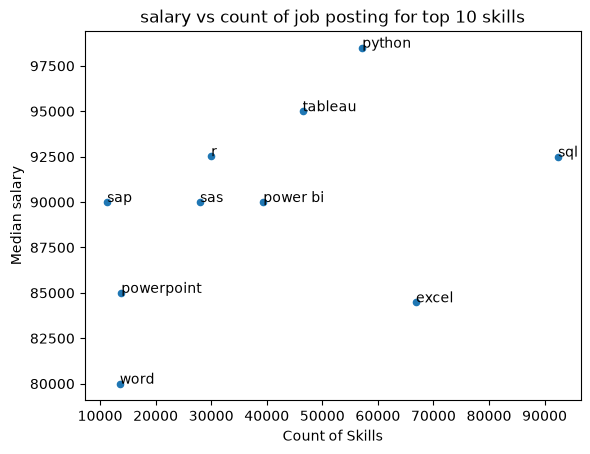

In [15]:
skills_stat = df_exploded.groupby('job_skills').agg(
    skills_count =('job_skills','count'),
    median_salary = ('salary_year_avg','median')

)

skills_stat = skills_stat.sort_values(by='skills_count',ascending = False).head(10)

skills_stat.plot(kind='scatter',x='skills_count',y='median_salary')
plt.xlabel('Count of Skills')
plt.ylabel('Median salary')
plt.title('salary vs count of job posting for top 10 skills')

for i, txt in enumerate(skills_stat.index):
    plt.text(skills_stat['skills_count'].iloc[i],skills_stat['median_salary'].iloc[i],txt)

# disadvantage :  no note for the scatter

In [13]:
skills_stat

,skills_count,median_salary
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0
